# YOLOv5n VisDrone Training
Make sure you have added the following datasets via (**+ Add Input**):
1. VisDrone dataset (with train/val images)

Set **Accelerator → GPU T4 x2** in Session options.
Set Persistence to variables and files in Session options.
Set Internet on in Session Options.


In [1]:
!pip install ultralytics tqdm pillow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 4.2 MB/s eta 0:00:00


In [2]:
import os

VISDRONE_INPUT = "/kaggle/input/datasets/dabiraomotoso/visdrone/VisDrone"          # folder of VisDrone dataset

OUTPUT_DIR = "/kaggle/working/runs/comparison2_yolo5n"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Print input contents to verify folder names
print("=== /kaggle/input contents ===")
for d in os.listdir("/kaggle/input"):
    print(" ", d)

=== /kaggle/input contents ===
  datasets


In [3]:
# Verifying expected folders exist
TRAIN_IMAGES  = os.path.join(VISDRONE_INPUT, "VisDrone2019-DET-train/images")
VAL_IMAGES    = os.path.join(VISDRONE_INPUT, "VisDrone2019-DET-val/images")
TEST_IMAGES   = os.path.join(VISDRONE_INPUT, "VisDrone2019-DET-test-challenge/images")
TRAIN_LABELS  = os.path.join(VISDRONE_INPUT, "VisDrone2019-DET-train/labels")
VAL_LABELS    = os.path.join(VISDRONE_INPUT, "VisDrone2019-DET-val/labels")

for path in [TRAIN_IMAGES, VAL_IMAGES, TEST_IMAGES, TRAIN_LABELS, VAL_LABELS]:
    status = "OK" if os.path.exists(path) else "NOT FOUND"
    print(f"[{status}] {path}")

[OK] /kaggle/input/datasets/dabiraomotoso/visdrone/VisDrone/VisDrone2019-DET-train/images
[OK] /kaggle/input/datasets/dabiraomotoso/visdrone/VisDrone/VisDrone2019-DET-val/images
[OK] /kaggle/input/datasets/dabiraomotoso/visdrone/VisDrone/VisDrone2019-DET-test-challenge/images
[OK] /kaggle/input/datasets/dabiraomotoso/visdrone/VisDrone/VisDrone2019-DET-train/labels
[OK] /kaggle/input/datasets/dabiraomotoso/visdrone/VisDrone/VisDrone2019-DET-val/labels


In [4]:
# ── Labels already converted in preprocessing notebook ───────────────────
print("Skipping conversion — labels already exist in dataset.")
print(f"  Train labels: {len(os.listdir(TRAIN_LABELS))} files")
print(f"  Val labels:   {len(os.listdir(VAL_LABELS))} files")

Skipping conversion — labels already exist in dataset.
  Train labels: 6471 files
  Val labels:   548 files


In [5]:
# Write data.yaml with my paths 
import yaml

data = {
    "path": VISDRONE_INPUT,
    "train": "VisDrone2019-DET-train/images",
    "val":   "VisDrone2019-DET-val/images",
    "test":  "VisDrone2019-DET-test-challenge/images",
    "nc": 10,
    "names": {
        0: "pedestrian",
        1: "people",
        2: "bicycle",
        3: "car",
        4: "van",
        5: "truck",
        6: "tricycle",
        7: "awning-tricycle",
        8: "bus",
        9: "motor"
    }
}

YAML_PATH = "/kaggle/working/data.yaml"
with open(YAML_PATH, "w") as f:
    yaml.dump(data, f, default_flow_style=False, sort_keys=False)

print("data.yaml written to:", YAML_PATH)
!cat /kaggle/working/data.yaml

data.yaml written to: /kaggle/working/data.yaml
path: /kaggle/input/datasets/dabiraomotoso/visdrone/VisDrone
train: VisDrone2019-DET-train/images
val: VisDrone2019-DET-val/images
test: VisDrone2019-DET-test-challenge/images
nc: 10
names:
  0: pedestrian
  1: people
  2: bicycle
  3: car
  4: van
  5: truck
  6: tricycle
  7: awning-tricycle
  8: bus
  9: motor


In [6]:
from ultralytics import YOLO

model = YOLO("yolov5n.pt")

results = model.train(
    data    = YAML_PATH,
    epochs  = 1,
    imgsz   = 640,
    batch   = 16,
    project = "/kaggle/working/runs",
    name    = "comparison2_yolo5n",
    exist_ok= True,
)
print("Sanity check passed!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PRO TIP 💡 Replace 'model=yolov5n.pt' with new 'model=yolov5nu.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.

Ultralytics 8.4.32 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, devic

In [7]:
from ultralytics import YOLO

model = YOLO("yolov5n.pt")

results = model.train(
    data     = YAML_PATH,
    epochs   = 200,
    imgsz    = 640,
    batch    = 16,
    patience = 50,
    project  = "/kaggle/working/runs",
    name     = "comparison2_yolo5n",
    exist_ok = True,
)

PRO TIP 💡 Replace 'model=yolov5n.pt' with new 'model=yolov5nu.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.

Ultralytics 8.4.32 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None,

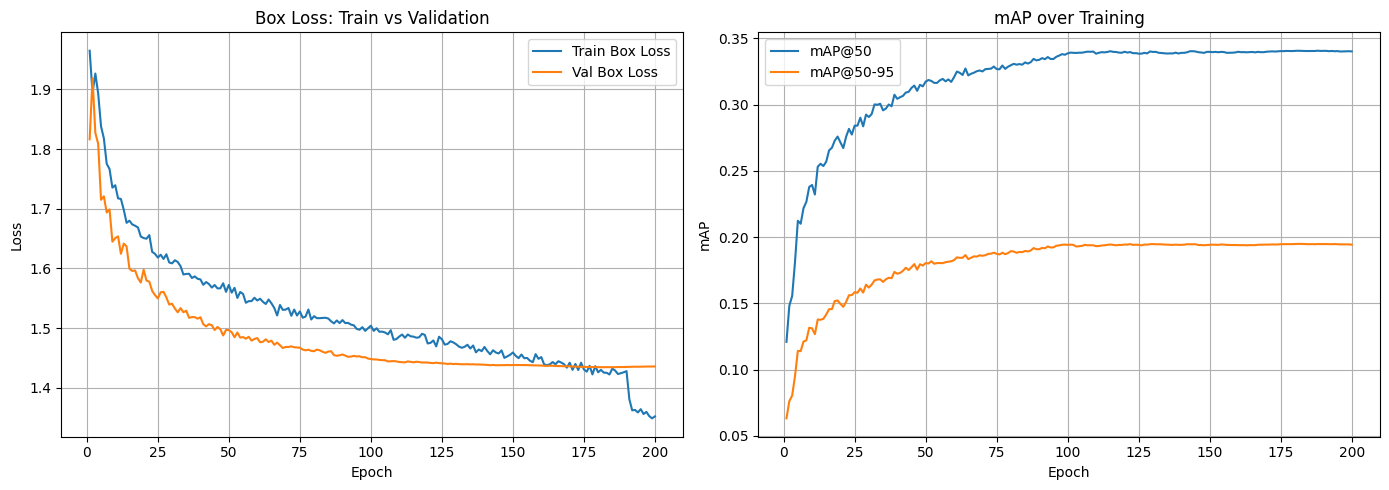

Plot saved.


In [8]:
# Plot training curves
import pandas as pd
import matplotlib.pyplot as plt

csv_path = "/kaggle/working/runs/comparison2_yolo5n/results.csv"
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
axes[0].plot(df["epoch"], df["val/box_loss"],   label="Val Box Loss")
axes[0].set_title("Box Loss: Train vs Validation")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(df["epoch"], df["metrics/mAP50(B)"],    label="mAP@50")
axes[1].plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP@50-95")
axes[1].set_title("mAP over Training")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("mAP")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("/kaggle/working/loss_curves.png", dpi=150)
plt.show()
print("Plot saved.")

In [9]:
import zipfile
import os

zip_path = "/kaggle/working/comparison2_yolo5n_export.zip"

to_include = [
    "/kaggle/working/runs",
    "/kaggle/working/loss_curves.png",
    "/kaggle/working/data.yaml"
]

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for path in to_include:
        if os.path.isdir(path):
            for root, dirs, files in os.walk(path):
                for file in files:
                    full_path = os.path.join(root, file)
                    arcname = os.path.relpath(full_path, "/kaggle/working")
                    zf.write(full_path, arcname)
        elif os.path.isfile(path):
            arcname = os.path.relpath(path, "/kaggle/working")
            zf.write(path, arcname)
        else:
            print(f"Not found: {path}")

print(f"Saved to: {zip_path}")

Saved to: /kaggle/working/comparison2_yolo5n_export.zip
